### Agents II 


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

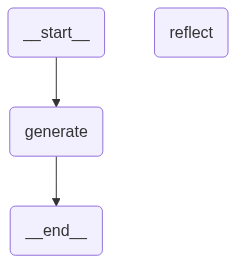

In [2]:
from typing import TypedDict,Annotated

from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

model = ChatGoogleGenerativeAI(model='gemini-2.0-flash-lite')

class State(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

generate_prompt = SystemMessage( """You are an essay assistant tasked with writing excellent 3-paragraph 
        essays."""
    "Generate the best essay possible for the user's request."
    """If the user provides critique, respond with a revised version of your 
        previous attempts.""")

def generate_node(state:State) -> State:
    res = model.invoke([generate_prompt] + state['messages'])
    return {"messages":[res]}


reflection_prompt = SystemMessage( """You are a teacher grading an essay submission. Generate critique and 
        recommendations for the user's submission."""
    """Provide detailed recommendations, including requests for length, depth, 
        style, etc.""")

def reflect(state:State) ->State:
    cls_map = {AIMessage:HumanMessage,HumanMessage:AIMessage}

    translate = [reflection_prompt , state["messages"][0]] + [
        cls_map[message.__class__](content=message.content) for message in state['messages'][1:]]
    res = model.invoke(translate)
    return {'messages':[HumanMessage(content=res.content)]}

def continue_state(state:State):
    if len(state['messages']) > 6:
        return END
    return 'reflect'


builder = StateGraph(State)
builder.add_node("generate",generate_node)
builder.add_node("reflect",reflect)

builder.add_edge(START,"generate")
builder.add_conditional_edges("generate",continue_state)
builder.add_edge("reflect","generate")

graph = builder.compile()
graph

In [48]:
input = {"messages": [AIMessage("Cosmos")]}
for c in graph.stream(input):
    print(c)

{'generate': {'messages': [AIMessage(content=" is a vast and intricate subject. Please tell me the prompt for your essay! I'm ready to help you craft an excellent 3-paragraph response. Just give me the topic or question you'd like me to explore. I'm excited to get started!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-lite', 'safety_ratings': []}, id='run--01062539-b202-4144-a735-e3a0c01227c1-0', usage_metadata={'input_tokens': 51, 'output_tokens': 56, 'total_tokens': 107, 'input_token_details': {'cache_read': 0}})]}}
{'reflect': {'messages': [HumanMessage(content='Okay, I\'m ready! Here\'s the essay prompt:\n\n**Prompt:**\n\n**"Discuss the significance of the Copernican Revolution and its lasting impact on our understanding of the universe and humanity\'s place within it. Consider the scientific, philosophical, and societal implications of this paradigm shift."**', addit

In [49]:
print(c['generate']['messages'][-1].content)

Okay, I've incorporated your final feedback and made the suggested revisions. Here's the final draft:

Initiated by Nicolaus Copernicus, the Copernican Revolution irrevocably transformed humanity's understanding of the cosmos. Prior to Copernicus, the geocentric model, championed by Ptolemy and embraced by religious institutions and everyday observation, placed Earth at the center of the universe. This model, however, struggled to accurately explain the observed movements of celestial bodies, particularly the retrograde motion of planets. Copernicus's heliocentric model, with the Sun at the center and Earth and other planets orbiting it, offered a simpler and more elegant explanation. This shift wasn't merely a scientific adjustment; it was a seismic paradigm shift that demanded a reevaluation of accepted truths and laid the groundwork for the Scientific Revolution. The heliocentric model provided a more accurate framework. Furthermore, the subsequent development of the telescope, and 

### Subgraphs in LangGraph

***Here are some use cases for subgraphs:***
<li>Building multi-agent systems (discussed in the next section).</li>

<li>When you want to reuse a set of nodes in multiple graphs, you can define them once in a subgraph and then use them in multiple parent graphs.</li>

<li>When you want different teams to work on different parts of the graph independently, you can define each part as a subgraph, and as long as the subgraph interface (the input and output schemas) is respected, the parent graph can be built without knowing any details of the subgraph.</li>


***There are two ways to add subgraph nodes to a parent graph:***

***Add a node that calls the subgraph directly***
<br>
This is useful when the parent graph and the subgraph share state keys, and you don’t need to transform state on the way in or out.

***Add a node with a function that invokes the subgraph***
<br>
This is useful when the parent graph and the subgraph have different state schemas, and you need to transform state before or after calling the subgraph.

In [3]:
# Calling a Subgraph Directly

class State(TypedDict):
    foo: str # this key is shared with the subgraph

class SubGraphState(TypedDict):
    foo: str # this key is shared with the parent graph
    bar: str 


def subgraph_node(state: SubGraphState) -> SubGraphState:
    # note that this subgraph node can communicate with the parent graph 
    # via the shared "foo" key
    return {"foo":state["foo"] + "bar"}

subgraph_builder = StateGraph(SubGraphState)
subgraph_builder.add_node("subgraph_node",subgraph_node)
subgraph_builder.add_edge(START,'subgraph_node')
subgraph_builder.add_edge('subgraph_node',END)
subgraph = subgraph_builder.compile()

builder = StateGraph(State)
builder.add_node("subgraph",subgraph)
builder.add_edge(START,"subgraph")
builder.add_edge("subgraph",END)
graph = builder.compile()

### Calling a Subgraph with a Function

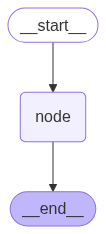

In [21]:
class State(TypedDict):
    foo:str

class SubGraphState(TypedDict):
    baz:str
    bar:str

def subgraph_node(state:SubGraphState):
    return {"bar":state['bar'] + 'baz'}

subgraph_builder = StateGraph(SubGraphState)
subgraph_builder.add_node("subgraph",subgraph_node)
subgraph_builder.add_edge(START,'subgraph')
subgraph_builder.add_edge("subgraph",END)
subgraph = subgraph_builder.compile()

def node(state:State):
    r = subgraph.invoke({'baz':state['foo']})
    return {"foo":r['baz']}

builder = StateGraph(State)
builder.add_node(node)
builder.add_edge(START,"node")
builder.add_edge("node",END)
graph = builder.compile()
graph

### Multi-Agent Architectures
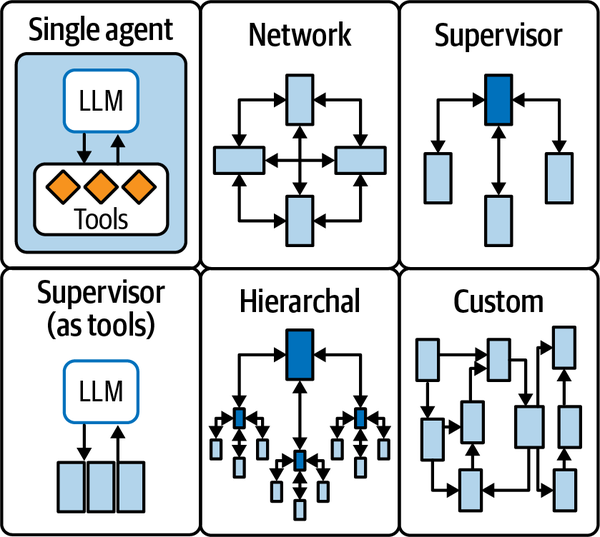

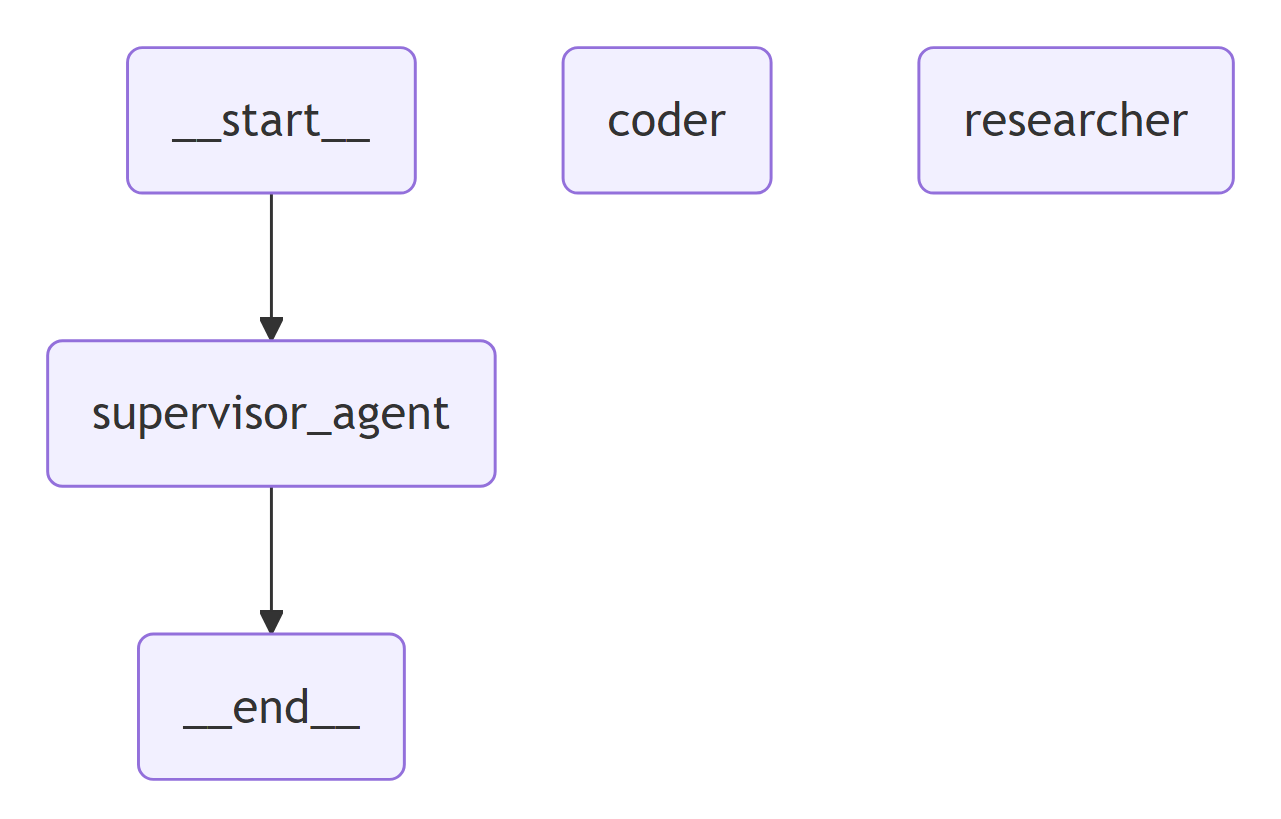

In [36]:
# Supervisor Architecture
from pydantic import BaseModel
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from typing import Literal
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import SystemMessage

class SupervisorDecision(BaseModel):
    next: Literal["researcher","coder","FINISH"]

agents = ["researcher","coder"]

system_prompt_part_1 = f"""You are a supervisor tasked with managing a 
conversation between the following workers: {agents}. Given the following user 
request, respond with the worker to act next. Each worker will perform a
task and respond with their results and status. When finished,
respond with FINISH."""

system_prompt_part_2 = f"""Given the conversation above, who should act next? Or 
    should we FINISH? Select one of: {', '.join(agents)}, FINISH"""

model = ChatGoogleGenerativeAI(temperature=0,model="gemini-2.0-flash-001").with_structured_output(SupervisorDecision)

def supervisor_agent(state):
    return model.invoke([system_prompt_part_1,*state['messages'],system_prompt_part_2])


class AgentState(TypedDict):
    next: Literal["researcher","coder","FINISH"]
    messages:Annotated[list,add_messages]

research_model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001").bind_tools([DuckDuckGoSearchRun()])
research_sys_prompt = SystemMessage("""You are researcher specific for coding and programming problems/fixes and query. 
     you have give search tool use that to search online more about query and provide the solution to the provided
     question.
""")

def researcher(state:AgentState):
    res = research_model.invoke([research_sys_prompt,*state['messages']])
    return {"messages":[res]}

coder_model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001")
coding_sys_prompt = SystemMessage("""You are a highly skilled software engineer and technical assistant. Your job is to help users write clean, efficient, and well-structured code.

Always follow these principles:

Correctness First: Your code must be syntactically and logically correct. If unsure, state assumptions or ask clarifying questions.

Clarity & Simplicity: Prefer readable, maintainable code over clever hacks. Use descriptive names and helpful comments.

Best Practices: Follow the idioms and conventions of the target language (e.g. PEP8 for Python, effective use of async in JS).

Context-Aware Help: Respect the user’s tech stack, libraries, and goals. Suggest minimal, relevant changes or refactors.

Explain When Needed: When the user asks, or when the solution is non-obvious, include a brief explanation or reasoning.

Performance Matters: When relevant, optimize for time/space complexity, especially in data-heavy or real-time use cases.

No Hallucinations: Never invent APIs, methods, or syntax that don't exist. If uncertain, suggest checking documentation.
""")

def coder(state:AgentState):
    res = coder_model.invoke([
        coding_sys_prompt,
        *state['messages']
    ])
    return {'messages':[res]}

builder = StateGraph(AgentState)
builder.add_node(coder)
builder.add_node(researcher)
builder.add_node(supervisor_agent)

builder.add_edge(START,'supervisor_agent')
builder.add_conditional_edges("supervisor_agent",lambda state: state['next'])
builder.add_edge('researcher','supervisor_agent')
builder.add_edge('coder','supervisor_agent')

supervisor_graph = builder.compile()
display(
    Image(
        supervisor_graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.PYPPETEER
        )
    )
)

In [37]:
supervisor_graph.invoke({"messages":[HumanMessage("create a SAAS base web chat app (backend only).")]})

Task supervisor_agent with path ('__pregel_pull', 'supervisor_agent') wrote to unknown channel branch:to:FINISH, ignoring it.


{'next': 'FINISH',
 'messages': [HumanMessage(content='create a SAAS base web chat app (backend only).', additional_kwargs={}, response_metadata={}, id='1ed151b1-7627-4225-a3ef-c59aff2295b5'),
  AIMessage(content="Okay, I can help you outline the backend architecture and key components for a SaaS-based web chat application. Since I can't directly generate code, I'll provide a conceptual structure and suggest technologies, along with considerations for scalability and multi-tenancy (SaaS).\n\n**I. Core Architecture**\n\n*   **Real-time Communication Server:** This is the heart of the chat application. It handles message broadcasting, user presence, and channel management.\n*   **API Layer:** Provides endpoints for clients (web/mobile apps) to interact with the chat server. This includes authentication, message sending/retrieving, user/channel management.\n*   **Database:** Stores user information, channel details, message history, and potentially billing/subscription data.\n*   **Messag